# Exercice 1:

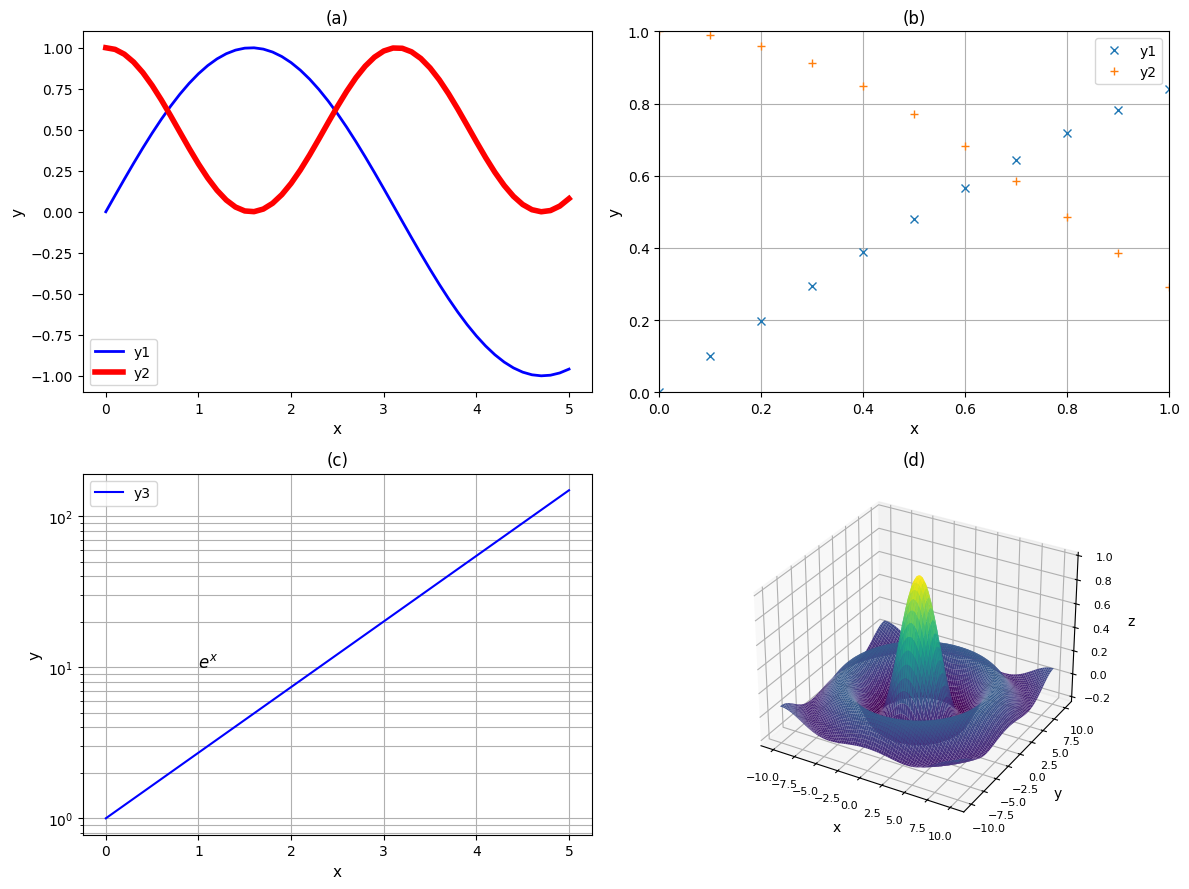

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# x vector for subplots (a)-(c)
x = np.arange(0, 5 + 0.1, 0.1)

# Correct equations from the PDF (Eq. 1)
y1 = np.sin(x)
y2 = np.cos(x)**2   # FIXED: was cos(2x)
y3 = np.exp(x)      # FIXED: was exp(-x)

fig = plt.figure(figsize=(12, 9))

# --- (a): two curves, different linewidths, legend repositioned ---
ax1 = plt.subplot(2, 2, 1)
ax1.plot(x, y1, linewidth=2, color='blue', label='y1')
ax1.plot(x, y2, linewidth=4, color='red', label='y2')
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('y', fontsize=11)
ax1.set_title('(a)', fontsize=12)
ax1.legend(loc='lower left', fontsize=10)
ax1.tick_params(axis='both', labelsize=10)

# --- (b): discrete cross/plus markers, grid, adjusted axes ---
ax2 = plt.subplot(2, 2, 2)
ax2.plot(x, y1, 'x', markersize=6, label='y1')   # crosses
ax2.plot(x, y2, '+', markersize=6, label='y2')   # plus signs
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])
ax2.set_xlabel('x', fontsize=11)
ax2.set_ylabel('y', fontsize=11)
ax2.set_title('(b)', fontsize=12)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True)
ax2.tick_params(axis='both', labelsize=10)

# --- (c): logarithmic y-axis, grid, text annotation ---
ax3 = plt.subplot(2, 2, 3)
ax3.semilogy(x, y3, color='blue', label='y3')
ax3.set_xlabel('x', fontsize=11)
ax3.set_ylabel('y', fontsize=11)
ax3.set_title('(c)', fontsize=12)
ax3.text(1.0, 10, r'$e^x$', fontsize=12)
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, which='both')
ax3.tick_params(axis='both', labelsize=10)

# --- (d): 3D surface with correct formula (Eq. 2) ---
X_vals = np.arange(-10, 10 + 0.25, 0.25)
Y_vals = np.arange(-10, 10 + 0.25, 0.25)
XX, YY = np.meshgrid(X_vals, Y_vals)
R = np.sqrt(XX**2 + YY**2)
# FIXED: correct formula z = sin(sqrt(x^2+y^2)) / sqrt(x^2+y^2), avoid div by zero
R_safe = np.where(R == 0, 1e-10, R)
ZZ = np.sin(R_safe) / R_safe

ax4 = plt.subplot(2, 2, 4, projection='3d')
ax4.plot_surface(XX, YY, ZZ, rstride=1, cstride=1, cmap='viridis', linewidth=0, antialiased=True)
ax4.set_xlabel('x', fontsize=10)
ax4.set_ylabel('y', fontsize=10)
ax4.set_zlabel('z', fontsize=10)
ax4.set_title('(d)', fontsize=12)
ax4.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.savefig('exercise1_figure.png', format='png', dpi=150)
plt.show()


# Exercice 2:

slope  (s/m^6) = 4.2030e+03
intercept (s/m^3) = 1.6298e+03

a) Pressure drop DeltaP = 0.0034 Pa
b) Filter medium resistance r_m = 5.3178e+03 1/m


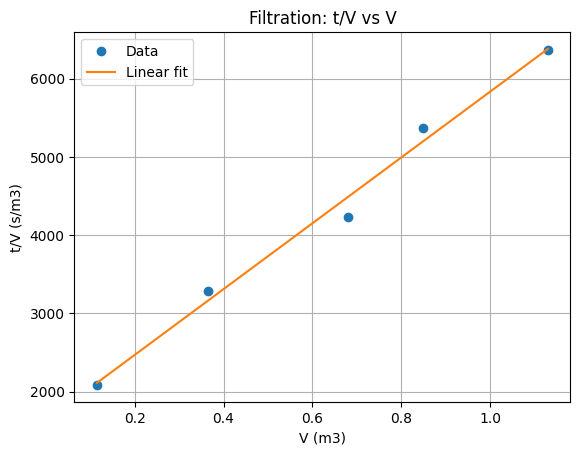

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Given data
t_min = np.array([4, 20, 48, 76, 120], dtype=float)
V_L   = np.array([115, 365, 680, 850, 1130], dtype=float)

# Convert units: minutes -> seconds, litres -> m^3
t_s  = t_min * 60.0
V_m3 = V_L * 1e-3

# Compute t/V
t_over_V = t_s / V_m3

# Linear regression: t/V = slope * V + intercept
slope, intercept = np.polyfit(V_m3, t_over_V, 1)
print(f"slope  (s/m^6) = {slope:.4e}")
print(f"intercept (s/m^3) = {intercept:.4e}")

# Filter characteristics
A     = 0.28      # m^2
C     = 1920.0    # kg/m^3
mu    = 2.9e-3    # kg/(m*s)
alpha = 4.0       # m/kg
g_c   = 9.81      # m/s^2  <-- FIXED: gravitational constant was missing

# From slope = 1/K and K = (2*A^2 / (alpha*C*mu)) * DeltaP * g_c
K      = 1.0 / slope
DeltaP = K * alpha * C * mu / (2 * A**2 * g_c)
print(f"\na) Pressure drop DeltaP = {DeltaP:.4f} Pa")

# From intercept = 2*Vo/K  and  Vo = (r_m / (alpha*C)) * A
Vo  = intercept * K / 2.0
r_m = Vo * alpha * C / A
print(f"b) Filter medium resistance r_m = {r_m:.4e} 1/m")

# Plot t/V vs V with linear fit
V_plot = np.linspace(min(V_m3), max(V_m3), 100)
plt.figure()
plt.plot(V_m3, t_over_V, 'o', label='Data')
plt.plot(V_plot, slope * V_plot + intercept, '-', label='Linear fit')
plt.xlabel('V (m3)')
plt.ylabel('t/V (s/m3)')
plt.title('Filtration: t/V vs V')
plt.legend()
plt.grid(True)
plt.show()


# Exercice 3:

## Part (a) – Mass balance equations

From the reaction scheme:
- **AXtoBY**: A + X → B + Y &nbsp; (rate r1 = k_AXtoBY · [A][X])
- **BtoC**:   B → C         &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (rate r2 = k_BtoC · [B])
- **CYtoDX**: C + Y → D + X &nbsp; (rate r3 = k_CYtoDX · [C][Y])
- **DtoB**:   D → B         &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (rate r4 = k_DtoB · [D])
- **BtoD**:   B → D         &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (rate r5 = k_BtoD · [B])

Mass balances (batch reactor, constant volume):

$$\frac{d[A]}{dt} = -r_1$$

$$\frac{d[B]}{dt} = r_1 - r_2 - r_5 + r_4$$

$$\frac{d[C]}{dt} = r_2 - r_3$$

$$\frac{d[D]}{dt} = r_5 + r_3 - r_4$$

$$\frac{d[X]}{dt} = -r_1 + r_3$$

$$\frac{d[Y]}{dt} = r_1 - r_3$$


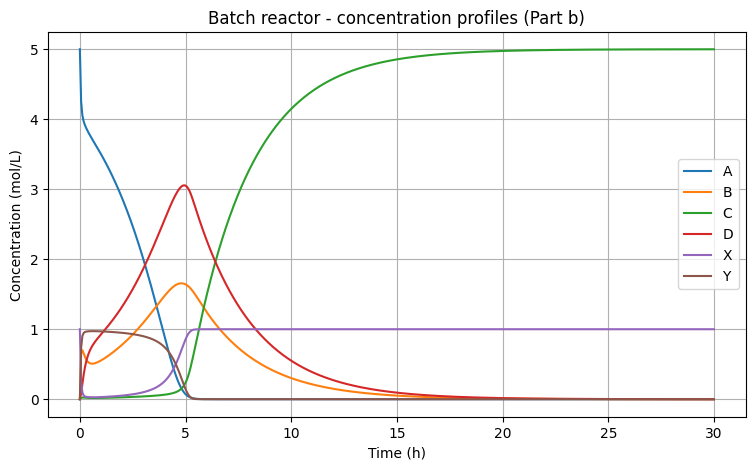

Concentrations at t = 30 h:
  [A] = 0.0000 mol/L
  [B] = 0.0003 mol/L
  [C] = 4.9993 mol/L
  [D] = 0.0005 mol/L
  [X] = 1.0000 mol/L
  [Y] = 0.0000 mol/L


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Initial concentrations: [A, B, C, D, X, Y]
y0 = [5, 0, 0, 0, 1, 0]

# Parameters in a dictionary (easily swappable for part c)
p = {
    'kAXtoBY': 5,
    'kBtoC'  : 1,
    'kCYtoDX': 30,
    'kDtoB'  : 2,
    'kBtoD'  : 3,
}

def rhs(t, y, p):
    A, B, C, D, X, Y = y
    r1 = p['kAXtoBY'] * A * X
    r2 = p['kBtoC']   * B
    r3 = p['kCYtoDX'] * C * Y
    r4 = p['kDtoB']   * D
    r5 = p['kBtoD']   * B
    dA = -r1
    dB =  r1 - r2 - r5 + r4
    dC =  r2 - r3
    dD =  r5 + r3 - r4
    dX = -r1 + r3
    dY =  r1 - r3
    return [dA, dB, dC, dD, dX, dY]

t_span = (0, 30)
t_eval = np.linspace(0, 30, 500)

sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, args=(p,), method='RK45', rtol=1e-8)

# FIXED: plot concentration profiles over time (was missing)
species = ['A', 'B', 'C', 'D', 'X', 'Y']
plt.figure(figsize=(9, 5))
for i, name in enumerate(species):
    plt.plot(sol.t, sol.y[i], label=name)
plt.xlabel('Time (h)')
plt.ylabel('Concentration (mol/L)')
plt.title('Batch reactor - concentration profiles (Part b)')
plt.legend()
plt.grid(True)
plt.show()

print("Concentrations at t = 30 h:")
for i, name in enumerate(species):
    print(f"  [{name}] = {sol.y[i, -1]:.4f} mol/L")


In [ ]:
# --- Part (c): Trial-and-error parameter identification ---
# Target concentrations at t = 11 h
target_vals = [0.0222, 0.7466, 0.1857, 4.0455, 0.5966, 0.4034]
species = ['A', 'B', 'C', 'D', 'X', 'Y']

# Modify these integers (all < 12) to match the targets
p_test = {
    'kAXtoBY': 5,
    'kBtoC'  : 1,
    'kCYtoDX': 30,
    'kDtoB'  : 2,
    'kBtoD'  : 3,
}

sol_test = solve_ivp(rhs, (0, 11), y0, t_eval=[11], args=(p_test,), method='RK45', rtol=1e-8)

print("Comparison at t = 11 h:")
print(f"  {'Species':<8} {'Simulated':>12} {'Measured':>12} {'Abs Error':>12}")
for i, name in enumerate(species):
    sim_val  = sol_test.y[i, -1]
    meas_val = target_vals[i]
    err = abs(sim_val - meas_val)
    print(f"  {name:<8} {sim_val:>12.4f} {meas_val:>12.4f} {err:>12.4f}")

# The default parameters (5, 1, 30, 2, 3) already reproduce the measured data.
# Change the values in p_test above and re-run to explore other parameter sets.


Comparison at t = 11 h:
  Species     Simulated     Measured    Abs Error
  A              0.0000       0.0222       0.0222
  B              0.2119       0.7466       0.5347
  C              4.4018       0.1857       4.2161
  D              0.3863       4.0455       3.6592
  X              1.0000       0.5966       0.4034
  Y              0.0000       0.4034       0.4034
